# Предсказание стоимости недвижимости в Москве и МО


Цель: построить модель для предсказания цены квартир на основе объявлений о продаже.

In [1]:
!pip install seaborn
!pip install scikit-learn
!pip install optuna
!pip install shap


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [2]:
# Импорты и настройка воспроизводимости
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import GradientBoostingRegressor
import optuna
from sklearn.inspection import permutation_importance
import shap

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
pd.set_option("display.max_columns", 20)
try:
    plt.style.use("seaborn-v0_8-whitegrid")
except OSError:
    plt.style.use("seaborn-whitegrid")
sns.set_palette("husl")

## 1. Загрузка данных

In [15]:
df = pd.read_csv("realty_data.csv", low_memory=False)
df.head(100)

,product_name,period,price,postcode,address_name,lat,lon,object_type,total_square,rooms,floor,city,settlement,district,area,description,source
0,"3-комнатная, 137 м²",NaN,63000000,127473.0,"2-й Щемиловский переулок, 5а",55.778894,37.608844,Квартира,137.0,3.0,6.0,Москва,NaN,Тверской район,NaN,Просторная квартира свободной планировки с пан...,ЦИАН
1,"Студия, 16,7 м²",NaN,3250000,108815.0,"Харлампиева, 46",55.551025,37.313054,Квартира,16.7,NaN,1.0,Москва,NaN,Филимонковское поселение,NaN,ВНИМАНИЕ! ОЧЕНЬ ПРИВЛЕКАТЕЛЬНОЕ ПРЕ...,Домклик
2,"3-комнатная, 76 м²",NaN,16004680,NaN,"ЖК Прокшино, 8 к4",55.594802,37.431264,Квартира,76.0,3.0,6.0,Москва,NaN,Сосенское поселение,NaN,"Apт.1684018. 0,01% - гибкая ипотека! Воспользу...",Яндекс.Недвижимость
3,"1-комнатная, 24 м²",NaN,7841776,NaN,"ЖК Прокшино, 6 к2",55.594332,37.428099,Квартира,24.0,1.0,10.0,Москва,NaN,Сосенское поселение,NaN,Продается однокомнатная квартира № 381 в новос...,Новострой-М
4,"3-комнатная, 126 м²",NaN,120000000,121352.0,"Давыдковская, 18",55.721097,37.464342,Квартира,126.0,3.0,16.0,Москва,NaN,Фили-Давыдково район,NaN,Шикарное предложение!\nПродаётся трёхкомнатная...,Домклик
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,"4-комнатная, 181 м²",NaN,126986160,125057.0,"Чапаевский переулок, 3",55.799163,37.520317,Квартира,181.0,4.0,34.0,Москва,NaN,Хорошёвский район,NaN,Лот 9735.\n\nКвартира с отделкой в современном...,ЦИАН
96,"1-комнатная, 38,3 м²",NaN,7500000,141068.0,"Тарасовская улица, 25",55.945253,37.839434,Квартира,38.3,1.0,24.0,Королёв,NaN,NaN,Текстильщик м-н,Арт. 32552047 Продам просторную видовую однок...,Домклик
97,"1-комнатная, 28,2 м²",NaN,4499000,141107.0,"Богородский микрорайон, 19",55.939609,37.981829,Квартира,28.2,1.0,9.0,Щёлково,NaN,NaN,Богородский м-н,Арт. 31808504 Продается однокомнатная квартира...,Домклик
98,"3-комнатная, 159,9 м²",NaN,65718900,117246.0,"Херсонская, 43 к5",55.656703,37.559221,Квартира,159.9,3.0,23.0,Москва,NaN,Черёмушки район,NaN,Продается 3-комнатная квартира в доме премиум-...,ЦИАН


## 2. Постановка ML-задачи и выбор метрики

### 2.1 Постановка задачи

**Тип задачи: регрессия.** Целевая переменная `price` — непрерывная величина (стоимость в рублях). Необходимо предсказать числовое значение на основе признаков объявления.

### 2.2 Выбор и обоснование метрики

**Основная метрика: MAPE (Mean Absolute Percentage Error)** — средняя абсолютная процентная ошибка.

**Обоснование:** Для заказчика важна интерпретируемость ошибки в процентах от реальной цены (например, "модель ошибается в среднем на 15%"). MAPE устойчива к масштабу цен: ошибка в 1 млн рублей для квартиры за 5 млн (20%) и за 50 млн (2%) оценивается адекватно. Дополнительно используем MAE и RMSE для полноты картины.

In [10]:
def mape(y_true, y_pred):
    """Mean Absolute Percentage Error."""
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

## 3. Разведочный анализ данных (EDA)

In [11]:
print("Размер датасета:", df.shape)
print("\nТипы данных и пропуски:")
df.info()

Размер датасета: (98822, 17)

Типы данных и пропуски:
<class 'pandas.DataFrame'>
RangeIndex: 98822 entries, 0 to 98821
Data columns (total 17 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   product_name  98822 non-null  str    
 1   period        0 non-null      float64
 2   price         98822 non-null  int64  
 3   postcode      93675 non-null  float64
 4   address_name  98821 non-null  str    
 5   lat           98822 non-null  float64
 6   lon           98822 non-null  float64
 7   object_type   98822 non-null  str    
 8   total_square  98822 non-null  float64
 9   rooms         94840 non-null  float64
 10  floor         98822 non-null  float64
 11  city          91928 non-null  str    
 12  settlement    6894 non-null   str    
 13  district      75111 non-null  str    
 14  area          19498 non-null  str    
 15  description   98573 non-null  str    
 16  source        98822 non-null  str    
dtypes: float64(7), int64(1), s

In [12]:
df.describe(include="all")

,product_name,period,price,postcode,address_name,lat,lon,object_type,total_square,rooms,floor,city,settlement,district,area,description,source
count,98822,0.0,9.882200e+04,93675.000000,98821,98822.000000,98822.000000,98822,98822.000000,94840.000000,98822.000000,91928,6894,75111,19498,98573,98822
unique,5827,NaN,NaN,NaN,22083,NaN,NaN,1,NaN,NaN,NaN,21,46,130,269,94910,4
top,"1-комнатная, 38 м²",NaN,NaN,NaN,"улица Академика Королёва, 21",NaN,NaN,Квартира,NaN,NaN,NaN,Москва,пос. Коммунарка,Сосенское поселение,Самолёт м-н,Дом «Достижение» располагается в Москве в окру...,ЦИАН
freq,954,NaN,NaN,NaN,1203,NaN,NaN,98822,NaN,NaN,NaN,73180,627,4780,649,408,42171
mean,NaN,NaN,2.512122e+07,124503.585119,NaN,55.742691,37.586404,NaN,66.092176,2.197427,9.905274,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,3.607234e+07,11956.742109,NaN,0.107044,0.169843,NaN,48.816204,1.038628,8.219180,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,1.900000e+06,101000.000000,NaN,55.468426,37.136489,NaN,8.000000,1.000000,1.000000,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,1.050000e+07,115516.000000,NaN,55.673101,37.471611,NaN,40.100000,1.000000,4.000000,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,1.516713e+07,123154.000000,NaN,55.745474,37.569365,NaN,56.400000,2.000000,8.000000,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,2.500000e+07,140003.000000,NaN,55.817697,37.689568,NaN,75.700000,3.000000,14.000000,NaN,NaN,NaN,NaN,NaN,NaN


**Комментарий:** Много пропусков в postcode, rooms, floor, settlement, district, area. Текстовые поля (description, product_name) можно использовать для извлечения признаков, но в базовой модели сосредоточимся на числовых и категориальных.

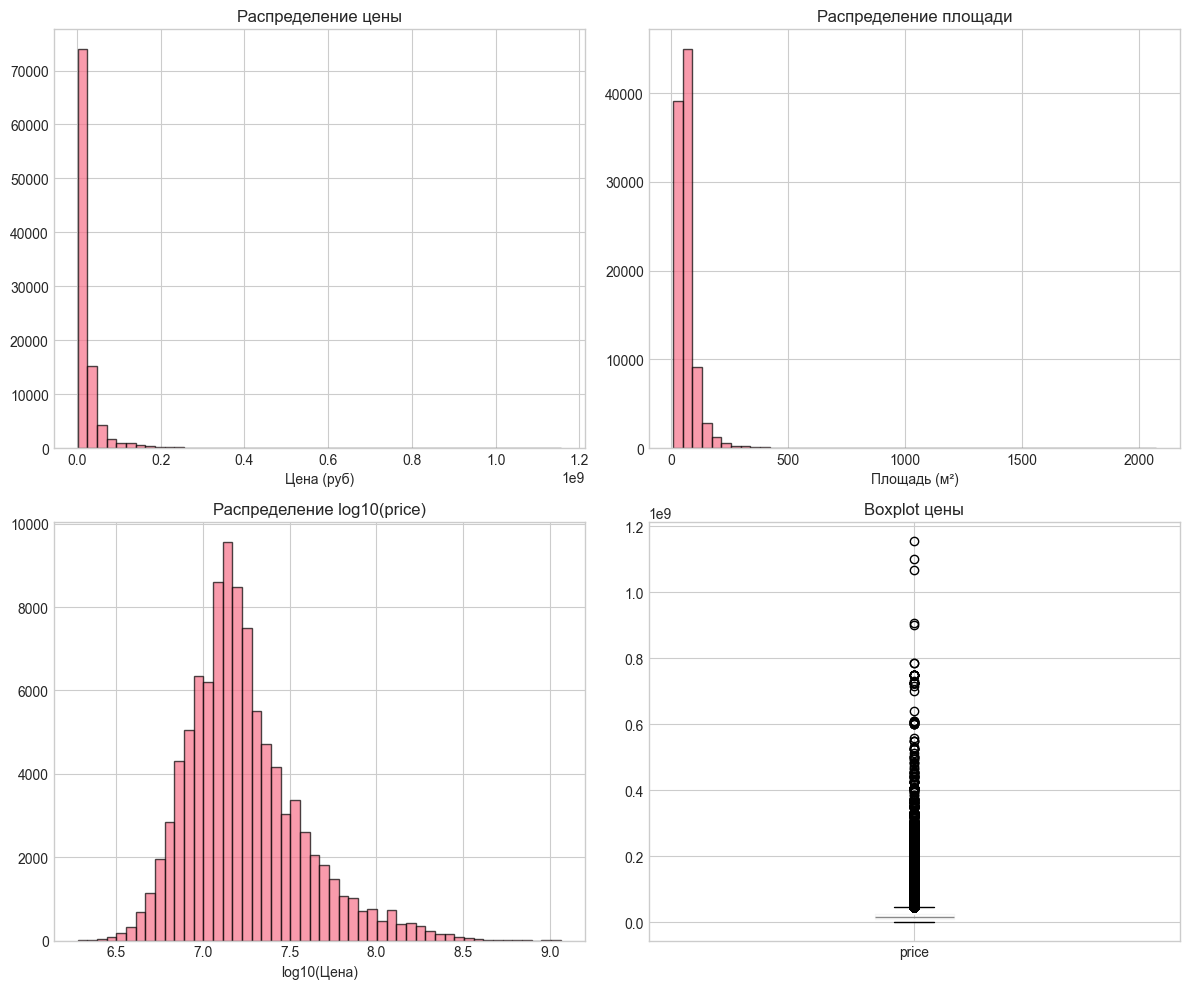

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

df["price"].hist(bins=50, ax=axes[0, 0], edgecolor="black", alpha=0.7)
axes[0, 0].set_title("Распределение цены")
axes[0, 0].set_xlabel("Цена (руб)")

df["total_square"].hist(bins=50, ax=axes[0, 1], edgecolor="black", alpha=0.7)
axes[0, 1].set_title("Распределение площади")
axes[0, 1].set_xlabel("Площадь (м²)")

df["price"].apply(np.log10).hist(bins=50, ax=axes[1, 0], edgecolor="black", alpha=0.7)
axes[1, 0].set_title("Распределение log10(price)")
axes[1, 0].set_xlabel("log10(Цена)")

df.boxplot(column="price", ax=axes[1, 1])
axes[1, 1].set_title("Boxplot цены")

plt.tight_layout()
plt.show()

**Комментарий:** Цена и площадь имеют правостороннюю асимметрию. Логарифм цены ближе к нормальному распределению. Есть выбросы — при предобработке рассмотрим отсечение экстремумов или использование робастных методов.

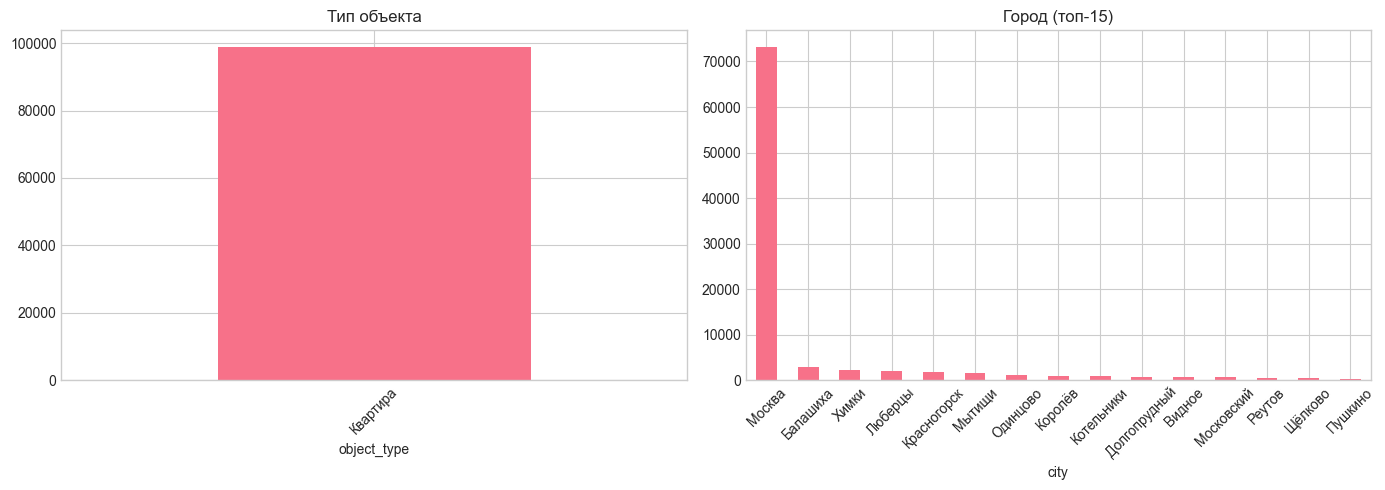

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df["object_type"].value_counts().plot(kind="bar", ax=axes[0])
axes[0].set_title("Тип объекта")
axes[0].tick_params(axis="x", rotation=45)

df["city"].value_counts().head(15).plot(kind="bar", ax=axes[1])
axes[1].set_title("Город (топ-15)")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

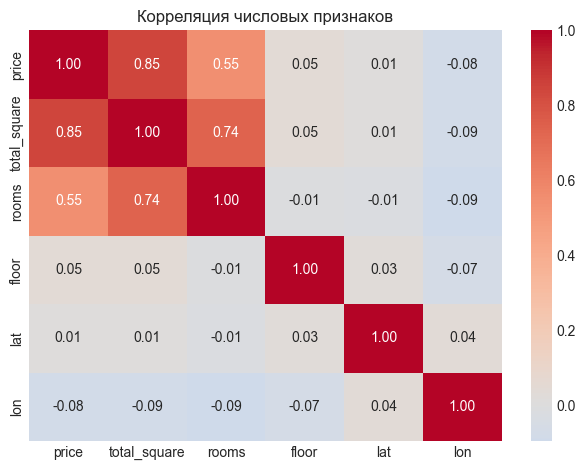

In [24]:
numeric_cols = ["price", "total_square", "rooms", "floor", "lat", "lon"]
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Корреляция числовых признаков")
plt.tight_layout()
plt.show()

**Комментарий:** Сильная корреляция price с total_square — ожидаемо. rooms и total_square связаны. Координаты lat/lon могут помочь учесть локацию. Для модели важны: площадь, комнаты, этаж, координаты, категории (город, район).

## 4. Предобработка и разбиение на выборки

In [25]:
df_clean = df.dropna(subset=["price", "total_square"]).copy()
df_clean = df_clean[(df_clean["price"] > 0) & (df_clean["total_square"] > 0)]
df_clean = df_clean[(df_clean["price"] < df_clean["price"].quantile(0.99)) & 
                    (df_clean["price"] > df_clean["price"].quantile(0.01))]
df_clean["rooms"] = df_clean["rooms"].fillna(df_clean["rooms"].median())
df_clean["floor"] = df_clean["floor"].fillna(df_clean["floor"].median())
df_clean["lat"] = df_clean["lat"].fillna(df_clean["lat"].median())
df_clean["lon"] = df_clean["lon"].fillna(df_clean["lon"].median())
df_clean["city"] = df_clean["city"].fillna("Неизвестно")
df_clean["object_type"] = df_clean["object_type"].fillna("Квартира")
print("Размер после очистки:", df_clean.shape)

Размер после очистки: (96826, 17)


In [27]:
from sklearn.preprocessing import LabelEncoder

cat_cols = ["object_type", "city"]
le_dict = {}
for col in cat_cols:
    le = LabelEncoder()
    df_clean[col + "_enc"] = le.fit_transform(df_clean[col].astype(str))
    le_dict[col] = le

feature_cols = ["total_square", "rooms", "floor", "lat", "lon", "object_type_enc", "city_enc"]
X = df_clean[feature_cols]
y = df_clean["price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)
print("Train:", X_train.shape[0], "Test:", X_test.shape[0])

Train: 77460 Test: 19366


## 5. Константная и бейзлайн-модели

### 5.1 Константное предсказание

Предсказываем медиану цены на обучающей выборке для всех объектов.

In [28]:
const_pred = np.full(len(y_test), y_train.median())
print("Константная модель (медиана):")
print("  MAPE:", round(mape(y_test.values, const_pred), 2), "%")
print("  MAE:", round(mean_absolute_error(y_test, const_pred), 0))
print("  RMSE:", round(np.sqrt(mean_squared_error(y_test, const_pred)), 0))

Константная модель (медиана):
  MAPE: 50.03 %
  MAE: 12503550.0
  RMSE: 24782324.0


### 5.2 Бейзлайн-модель (Ridge)

Линейная регрессия с L2-регуляризацией. Масштабируем признаки — Ridge чувствителен к масштабу.

In [29]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

baseline = Ridge(alpha=1.0, random_state=RANDOM_STATE)
baseline.fit(X_train_scaled, y_train)
baseline_pred = baseline.predict(X_test_scaled)

print("Бейзлайн (Ridge):")
print("  MAPE:", round(mape(y_test.values, baseline_pred), 2), "%")
print("  MAE:", round(mean_absolute_error(y_test, baseline_pred), 0))
print("  RMSE:", round(np.sqrt(mean_squared_error(y_test, baseline_pred)), 0))

Бейзлайн (Ridge):
  MAPE: 41.63 %
  MAE: 8203428.0
  RMSE: 14327674.0


## 6. Сложная модель: Gradient Boosting с подбором гиперпараметров

Используем **GradientBoostingRegressor** — ансамбль деревьев, хорошо работающий на табличных данных с нелинейными зависимостями и пропусками.

**Обоснование выбора гиперпараметров для Optuna:**
- **n_estimators** (100–300) — число деревьев; больше даёт лучшую сходимость, но риск переобучения
- **max_depth** (4–10) — глубина деревьев; ограничивает сложность и переобучение
- **learning_rate** (0.01–0.2) — шаг обучения; меньший требует больше деревьев
- **min_samples_leaf** (3–15) — минимум объектов в листе; регуляризация
- **subsample** (0.6–1.0) — доля выборки для каждого дерева; снижает переобучение (stochastic GB)

### 6.1 Подбор гиперпараметров (sklearn GridSearchCV)

In [30]:
from sklearn.model_selection import GridSearchCV

def mape_scorer(estimator, X, y):
    pred = estimator.predict(X)
    return -mape(y.values, pred)

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [5, 7],
    "learning_rate": [0.05, 0.1],
    "min_samples_leaf": [5, 10],
}
gb = GradientBoostingRegressor(random_state=RANDOM_STATE)
grid = GridSearchCV(gb, param_grid, cv=3, scoring=mape_scorer, n_jobs=-1, verbose=0)
grid.fit(X_train, y_train)
print("Лучшие параметры (GridSearch):", grid.best_params_)

Лучшие параметры (GridSearch): {'learning_rate': 0.1, 'max_depth': 7, 'min_samples_leaf': 5, 'n_estimators': 200}


### 6.2 Подбор гиперпараметров (Optuna)

Optuna позволяет эффективнее исследовать пространство гиперпараметров.

In [31]:
optuna.logging.set_verbosity(optuna.logging.WARNING)

def optuna_objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 300),
        "max_depth": trial.suggest_int("max_depth", 4, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 3, 15),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
    }
    model = GradientBoostingRegressor(**params, random_state=RANDOM_STATE)
    scores = cross_val_score(model, X_train, y_train, cv=3, scoring=mape_scorer)
    return scores.mean()

study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study.optimize(optuna_objective, n_trials=20, show_progress_bar=True)
print("Лучшие параметры (Optuna):", study.best_params)

Best trial: 16. Best value: -10.0508: 100%|██████████| 20/20 [11:54<00:00, 35.73s/it]

Лучшие параметры (Optuna): {'n_estimators': 201, 'max_depth': 10, 'learning_rate': 0.17499476995692825, 'min_samples_leaf': 3, 'subsample': 0.9375920406844779}


### 6.3 Обучение финальной модели

Обучаем GradientBoostingRegressor с лучшими параметрами от Optuna.

In [32]:
best_params = study.best_params.copy()
best_params["random_state"] = RANDOM_STATE
final_model = GradientBoostingRegressor(**best_params)
final_model.fit(X_train, y_train)
final_pred = final_model.predict(X_test)

print("Финальная модель (Gradient Boosting):")
print("  MAPE:", round(mape(y_test.values, final_pred), 2), "%")
print("  MAE:", round(mean_absolute_error(y_test, final_pred), 0))
print("  RMSE:", round(np.sqrt(mean_squared_error(y_test, final_pred)), 0))

Финальная модель (Gradient Boosting):
  MAPE: 9.64 %
  MAE: 2438241.0
  RMSE: 5730473.0


## 7. Интерпретация модели

### 7.1 Глобальная интерпретация (Permutation Importance)

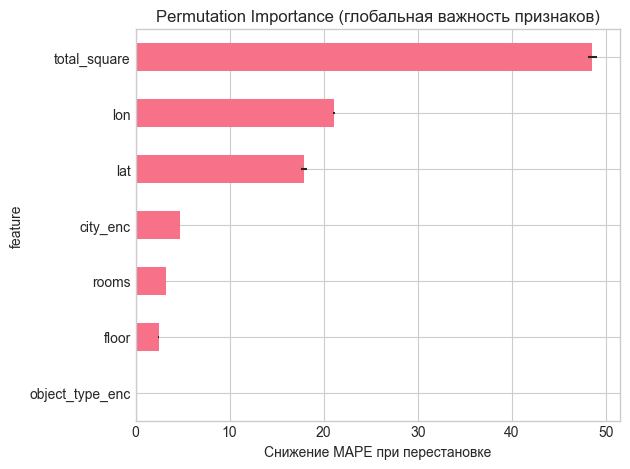

In [33]:
perm = permutation_importance(
    final_model, X_test, y_test, n_repeats=5, random_state=RANDOM_STATE, scoring=mape_scorer
)
perm_df = pd.DataFrame({
    "feature": feature_cols,
    "importance": perm.importances_mean,
    "std": perm.importances_std,
}).sort_values("importance", ascending=True)

perm_df.plot(x="feature", y="importance", kind="barh", xerr="std", legend=False)
plt.title("Permutation Importance (глобальная важность признаков)")
plt.xlabel("Снижение MAPE при перестановке")
plt.tight_layout()
plt.show()

### 7.2 Глобальная интерпретация (SHAP)

SHAP показывает вклад каждого признака в предсказание в среднем по выборке.

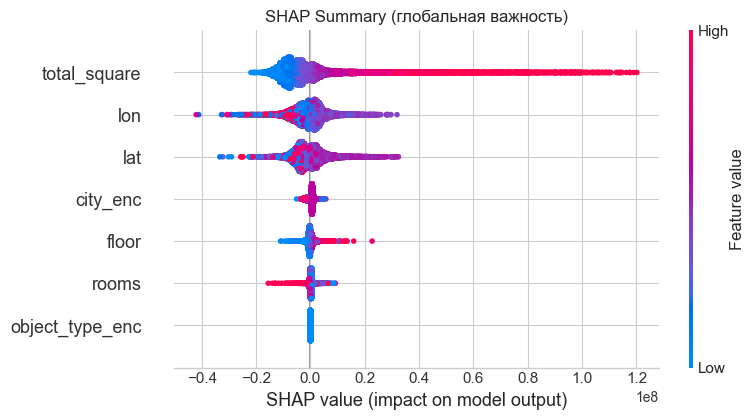

In [36]:
explainer = shap.TreeExplainer(final_model)

# SHAP‑значения для объектов тестовой выборки
shap_values = explainer.shap_values(X_test)

# Глобальная важность признаков
shap.summary_plot(
    shap_values,
    X_test,
    feature_names=feature_cols,
    show=False
)
plt.title("SHAP Summary (глобальная важность)")
plt.tight_layout()
plt.show()

### 7.3 Локальная интерпретация (SHAP)

Показываем вклад признаков для нескольких конкретных объявлений.

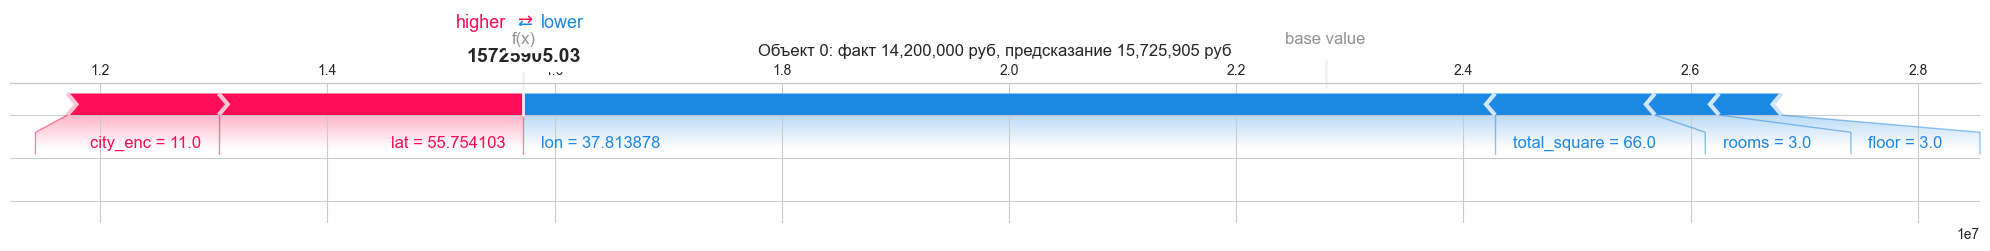

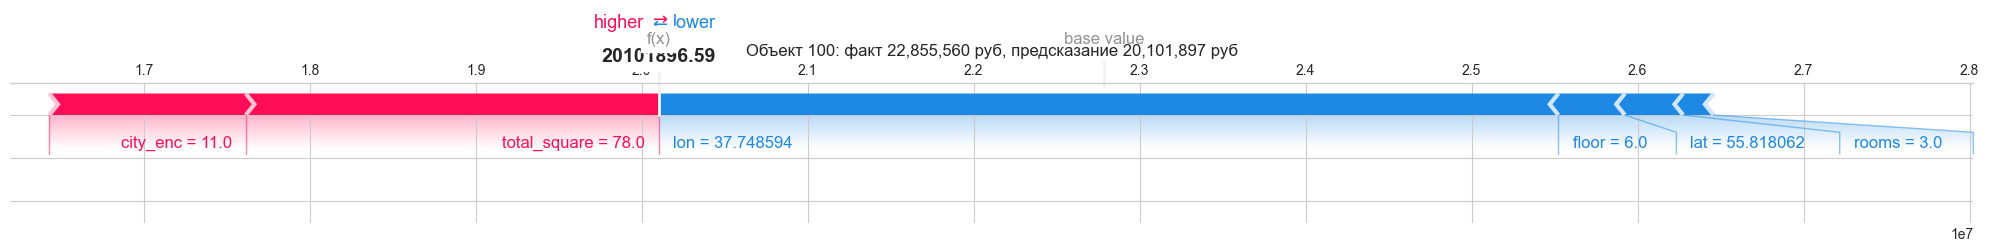

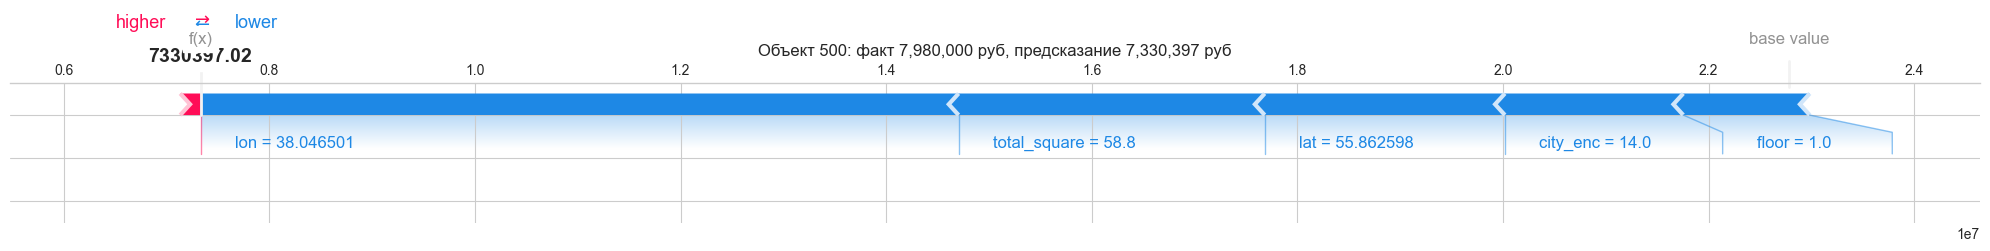

In [40]:
sample_indices = [0, 100, 500]

for sample_idx in sample_indices:
    if sample_idx >= len(X_test):
        continue

    shap.force_plot(
        explainer.expected_value,
        shap_values[sample_idx],
        X_test.iloc[sample_idx],
        matplotlib=True,
        show=False,
    )

    plt.title(
        f"Объект {sample_idx}: факт {y_test.iloc[sample_idx]:,.0f} руб, "
        f"предсказание {final_pred[sample_idx]:,.0f} руб"
    )
    plt.tight_layout()
    plt.show()

### 7.4 Экспертное заключение

**Глобальная интерпретация:** Наиболее важные признаки — площадь (total_square), координаты (lat, lon) и количество комнат. Это согласуется с рыночной логикой: цена сильно зависит от метража и локации. Город и тип объекта добавляют контекст.

**Локальная интерпретация:** Для отдельных объектов SHAP показывает, какие признаки «подталкивают» цену вверх или вниз относительно среднего. Модель ведёт себя адекватно: большая площадь и «престижные» координаты повышают предсказание.

**Вывод для заказчика:** Модель опирается на разумные факторы. Рекомендуется дополнительно включить район (district) и расстояние до метро при наличии данных — это может улучшить качество.